# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev-explainable-clustering-for-prototypes-IEMOCAP https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.audio_features import pooled_feature_dim
from src.utils.naming import (
    model_name_to_slug,
    pooled_feature_dir_name
)

DATASET_ID = "iemocap_speech_4class"
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / DATASET_ID
AUDIO_DIR = RAW_DIR / "audio"

# (model_name, dimension_of_the_original_vectors_generated_by_the_model)
FEATURE_EXTRACTOR = ("microsoft/wavlm-large", 1024)

FEATURE_EXTRACTOR_NAME, ENCODER_EMBEDDING_DIM = FEATURE_EXTRACTOR
FEATURE_EXTRACTOR_ID = model_name_to_slug(FEATURE_EXTRACTOR_NAME)
FEATURE_POOLING = "mean_std"
FEATURE_DIM = pooled_feature_dim(ENCODER_EMBEDDING_DIM, FEATURE_POOLING)
MIN_DURATION_SECONDS = 2.0
MAX_DURATION_SECONDS = 15.0
DURATION_FILTER_ID = f"dur_gt_{MIN_DURATION_SECONDS:g}_le_{MAX_DURATION_SECONDS:g}"

FEATURE_RUN_ID = f"{DATASET_ID}_{pooled_feature_dir_name(FEATURE_EXTRACTOR_NAME, FEATURE_POOLING)}_{DURATION_FILTER_ID}"
BLACK_BOX_RUN_ID = f"blackbox_{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{DURATION_FILTER_ID}"
BLACK_BOX_EMBEDDING_RUN_ID = f"{BLACK_BOX_RUN_ID}_penultimate_l2"

FEATURE_DIR = DATA_DIR / "features" / FEATURE_RUN_ID
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / BLACK_BOX_RUN_ID
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / BLACK_BOX_RUN_ID
BLACK_BOX_EMBEDDING_DIR = DATA_DIR / "features" / BLACK_BOX_EMBEDDING_RUN_ID

FEATURE_EXTRACTION_BATCH_SIZE = 8
FEATURE_EXTRACTION_NUM_WORKERS = 0 # set this to 2 or 4, if using Colab
RANDOM_STATE = 42

PROTOTYPE_CLUSTERING_RUN_ID = f"prototype_clustering_{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{DURATION_FILTER_ID}"
PROTOTYPE_CLUSTERING_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / PROTOTYPE_CLUSTERING_RUN_ID
PROTOTYPE_CLUSTERING_REPORT_DIR = PROJECT_ROOT / "reports" / PROTOTYPE_CLUSTERING_RUN_ID

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download IEMOCAP Speech

In [2]:
from src.preprocessing.download_iemocap import download_iemocap

metadata = download_iemocap(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

,file_name,session_id,emotion,label,audio_path,duration_seconds
0,Session1_00000.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,9.331188
1,Session1_00001.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.930000
2,Session1_00002.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,5.723500
3,Session1_00003.wav,Ses01,neutral,2,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,5.652500
4,Session1_00004.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,5.769938
5,Session1_00005.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.560000
6,Session1_00006.wav,Ses01,neutral,2,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,4.215000
7,Session1_00007.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,3.886813
8,Session1_00008.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,4.250000
9,Session1_00009.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,3.030500


## 3. Extract Frozen Audio Encoder Features

In [ ]:
from src.preprocessing.extract_audio_features import extract_audio_features

feature_paths = extract_audio_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    model_name=FEATURE_EXTRACTOR_NAME,
    expected_encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    num_workers=FEATURE_EXTRACTION_NUM_WORKERS,
    min_duration_seconds=MIN_DURATION_SECONDS,
    max_duration_seconds=MAX_DURATION_SECONDS,
    overwrite=True
)

feature_paths

## 4. Dataset Statistics

In [3]:
from src.data.iemocap import load_features, print_dataset_statistics

_, feature_metadata = load_features(FEATURE_DIR, mmap_mode="r")
print_dataset_statistics(feature_metadata)

Total samples: 4509
Sessions: 5
Audio duration: 6.18 hours
Duration range: 2.00s - 14.96s

Samples per emotion:
emotion  sample_count  percentage
  angry           937   20.780661
  happy          1333   29.563096
neutral          1312   29.097361
    sad           927   20.558882


## 5. Train the Black-Box Classifier

In [ ]:
from src.data.iemocap import EMOTION_NAMES
from src.training.train_blackbox import TrainingConfig, train_blackbox

SPLIT_STRATEGY = "sample_stratified"
#SPLIT_STRATEGY = "speaker_independent" # with this mirror, this is session-independent

training_config = TrainingConfig(
    input_dim=FEATURE_DIM,
    feature_extractor_name=FEATURE_EXTRACTOR_NAME,
    encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    hidden_dims=(256, 128),
    num_classes=len(EMOTION_NAMES),
    batch_size=64,
    epochs=100,
    dropout=0.25,
    learning_rate=2e-4,
    weight_decay=5e-4,
    split_strategy=SPLIT_STRATEGY,
    speaker_column="session_id", # for compatibility with CREMA-D code
    early_stopping_patience=15,
    #lr_scheduler=None, # set explicitly to None to disable the default scheduler
    scheduler_patience=6,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config
)

/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/src/data/iemocap.py:188: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.labels = torch.as_tensor(


Training black-box model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train loss 1.2588, acc 0.3973, macro F1 0.3892 | val loss 1.1349, acc 0.5163, macro F1 0.5066, weighted F1 0.4891 | lr 2.00e-04 | best
Epoch 002 | train loss 1.0947, acc 0.5086, macro F1 0.5044 | val loss 0.9754, acc 0.5695, macro F1 0.5621, weighted F1 0.5476 | lr 2.00e-04 | best
Epoch 003 | train loss 0.9656, acc 0.5786, macro F1 0.5801 | val loss 0.9072, acc 0.5991, macro F1 0.5965, weighted F1 0.5845 | lr 2.00e-04 | best
Epoch 004 | train loss 0.9044, acc 0.6046, macro F1 0.6063 | val loss 0.8581, acc 0.6672, macro F1 0.6721, weighted F1 0.6675 | lr 2.00e-04 | best
Epoch 005 | train loss 0.8662, acc 0.6239, macro F1 0.6279 | val loss 0.8459, acc 0.6391, macro F1 0.6428, weighted F1 0.6332 | lr 2.00e-04 | patience 1/15
Epoch 006 | train loss 0.8381, acc 0.6410, macro F1 0.6457 | val loss 0.8170, acc 0.6509, macro F1 0.6482, weighted F1 0.6390 | lr 2.00e-04 | patience 2/15
Epoch 007 | train loss 0.8040, acc 0.6553, macro F1 0.6592 | val loss 0.8683, acc 0.6302, macro F1 0

## 6. Evaluate the Black-Box Classifier

In [5]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox
from src.evaluation.metrics import print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    0.7770
Macro F1:    0.7803
Weighted F1: 0.7761

Classification report:
emotion precision recall f1_score  support
  angry    0.8052 0.8794   0.8407      141
  happy    0.8021 0.7500   0.7752      200
neutral    0.7540 0.7157   0.7344      197
    sad    0.7450 0.7986   0.7708      139


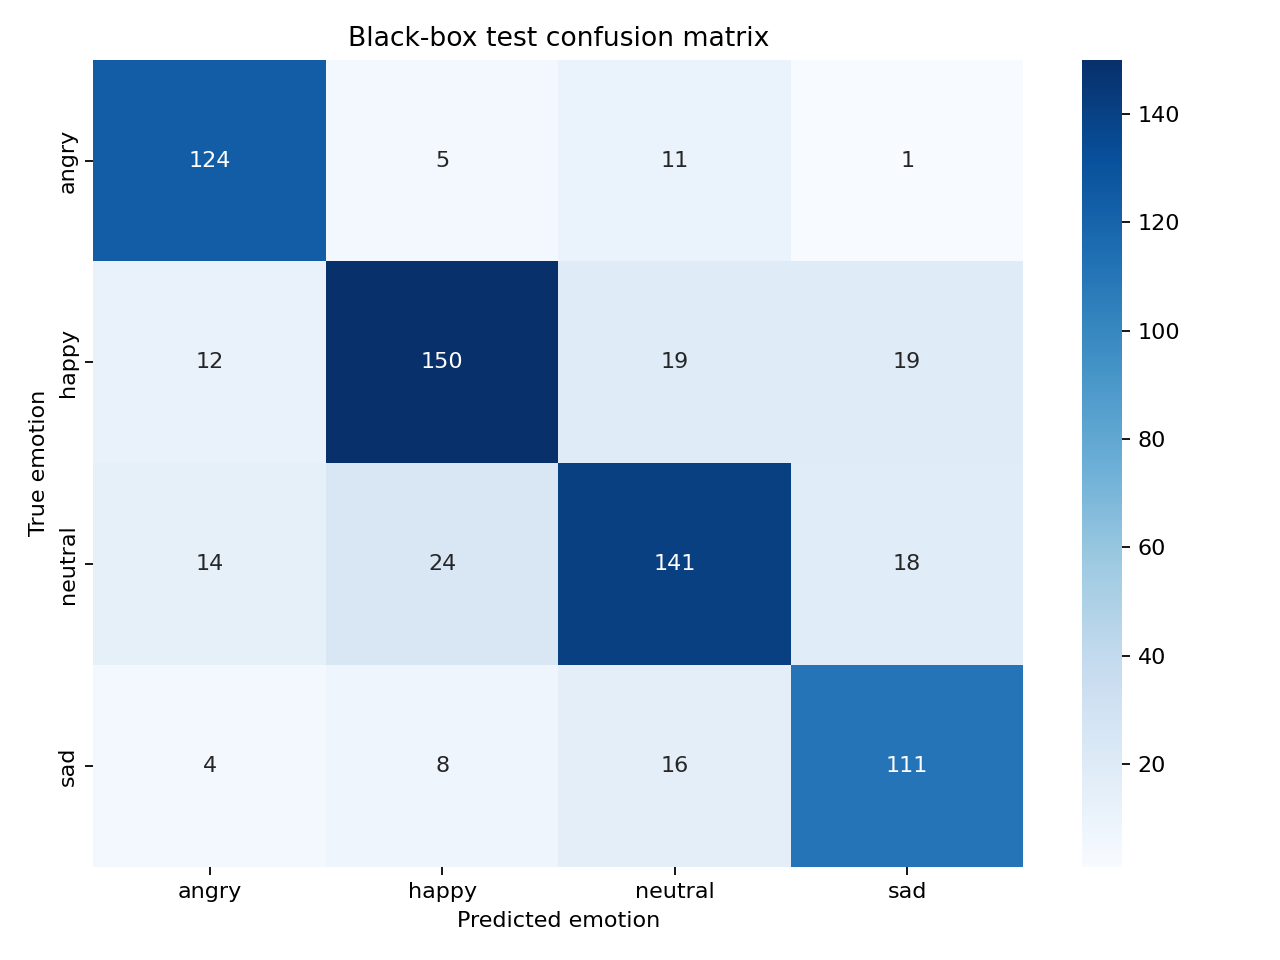

In [6]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))

## 7. Visualize Embedding Spaces

Project the pooled audio encoder features and the trained black-box penultimate representations to two PCA dimensions.


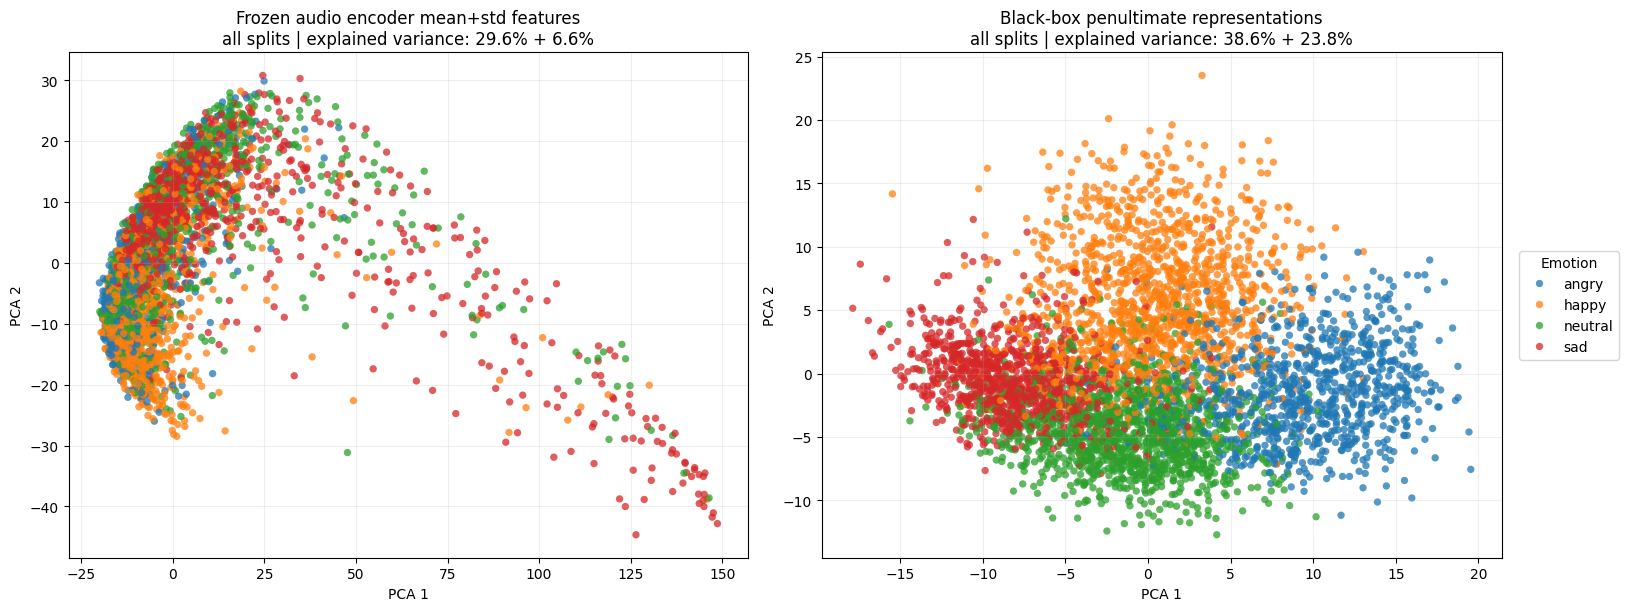

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/blackbox_iemocap_speech_4class_wavlm_large_dur_gt_2_le_15/all_embedding_pca.png')

In [7]:
from src.utils.visualize import plot_blackbox_embedding_pca

split_to_visualize = "all"

embedding_pca_result = plot_blackbox_embedding_pca(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split=split_to_visualize,
    output_path=BLACK_BOX_REPORT_DIR / f"{split_to_visualize}_embedding_pca.png",
    random_state=RANDOM_STATE
)

embedding_pca_result["output_path"]

## 8. Extract Black-Box Penultimate Embeddings

Extract the 128-dimensional representation before the final black-box classification layer and save its L2-normalized version.

In [8]:
from src.preprocessing.extract_blackbox_embeddings import extract_blackbox_penultimate_embeddings_l2

blackbox_embedding_paths = extract_blackbox_penultimate_embeddings_l2(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    output_dir=BLACK_BOX_EMBEDDING_DIR,
    batch_size=256,
    overwrite=True
)

blackbox_embedding_paths

Extracting black-box penultimate embeddings:   0%|          | 0/18 [00:00<?, ?it/s]

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_iemocap_speech_4class_wavlm_large_dur_gt_2_le_15_penultimate_l2/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_iemocap_speech_4class_wavlm_large_dur_gt_2_le_15_penultimate_l2/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_iemocap_speech_4class_wavlm_large_dur_gt_2_le_15_penultimate_l2/embedding_config.json')}

## 9. Prototype Clustering Grid Search

Fit K-means on the training split only, with K clusters per emotion. Each centroid is mapped to the nearest real training sample of the same emotion, and these real prototypes are used for classification. Select K and top-N on the validation split.

In [9]:
from src.data.iemocap import EMOTION_NAMES
from src.training.train_prototype_clustering import (
    PrototypeClusteringTrainingConfig,
    train_prototype_clustering
)

prototype_training_config = PrototypeClusteringTrainingConfig(
    embedding_dim=128,
    num_classes=len(EMOTION_NAMES),
    cluster_counts=(1, 2, 3, 4, 5),
    top_ns=(1, 3, 5, 7, 9),
    monitor_metric="macro_f1",
    random_state=RANDOM_STATE
)

prototype_training_results = train_prototype_clustering(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    output_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    config=prototype_training_config
)

K=01, top-N=01 | val acc 0.7234, macro F1 0.7259, weighted F1 0.7205
K=01, top-N=03 | val acc 0.7234, macro F1 0.7259, weighted F1 0.7205
K=02, top-N=01 | val acc 0.7382, macro F1 0.7404, weighted F1 0.7365
K=02, top-N=03 | val acc 0.7115, macro F1 0.7136, weighted F1 0.7067
K=02, top-N=05 | val acc 0.7101, macro F1 0.7115, weighted F1 0.7050
K=02, top-N=07 | val acc 0.7101, macro F1 0.7116, weighted F1 0.7050
K=03, top-N=01 | val acc 0.7411, macro F1 0.7440, weighted F1 0.7404
K=03, top-N=03 | val acc 0.7234, macro F1 0.7253, weighted F1 0.7195
K=03, top-N=05 | val acc 0.7308, macro F1 0.7325, weighted F1 0.7277
K=03, top-N=07 | val acc 0.7189, macro F1 0.7195, weighted F1 0.7143
K=03, top-N=09 | val acc 0.7234, macro F1 0.7248, weighted F1 0.7197
K=04, top-N=01 | val acc 0.7278, macro F1 0.7299, weighted F1 0.7267
K=04, top-N=03 | val acc 0.7382, macro F1 0.7406, weighted F1 0.7363
K=04, top-N=05 | val acc 0.7382, macro F1 0.7401, weighted F1 0.7358
K=04, top-N=07 | val acc 0.7293, m

## 10. Evaluate Prototype Clustering Classifier

In [23]:
from src.evaluation.evaluate_prototype_clustering import evaluate_prototype_clustering
from src.evaluation.metrics import print_classification_metrics

prototype_test_metrics = evaluate_prototype_clustering(
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    split="test",
    output_dir=PROTOTYPE_CLUSTERING_REPORT_DIR
)

print_classification_metrics(prototype_test_metrics)

Accuracy:    0.7710
Macro F1:    0.7762
Weighted F1: 0.7700

Classification report:
emotion precision recall f1_score  support
  angry    0.8133 0.8652   0.8385      141
  happy    0.7732 0.7500   0.7614      200
neutral    0.7405 0.6954   0.7173      197
    sad    0.7635 0.8129   0.7875      139


## 11. Evaluate Prototype Surrogate Fidelity

Measure how often the clustering surrogate matches the black-box predictions on the test split.

In [11]:
from src.explainability.surrogate_fidelity import print_clustering_surrogate_fidelity_accuracy

surrogate_fidelity_metrics = print_clustering_surrogate_fidelity_accuracy(
    blackbox_checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    prototype_model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test"
)

Accuracy against black-box predictions: 0.9631 (652/677)


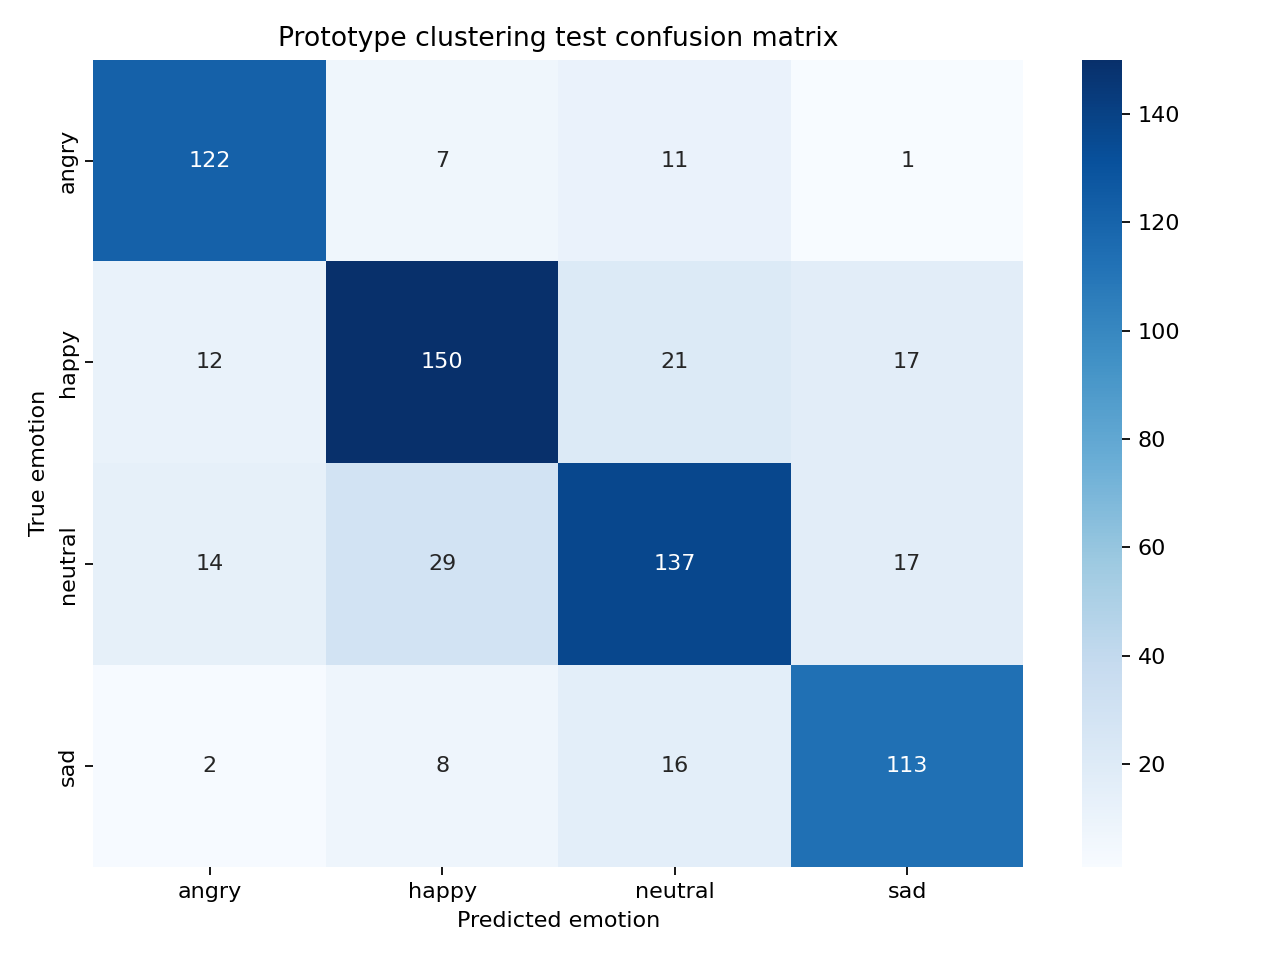

In [12]:
from IPython.display import Image, display

prototype_confusion_matrix_path = PROTOTYPE_CLUSTERING_REPORT_DIR / "test_confusion_matrix.png"
if prototype_confusion_matrix_path.exists():
    display(Image(filename=str(prototype_confusion_matrix_path)))

## 12. Visualize Prototype Embedding Space

Project the saved 128-dimensional L2-normalized black-box embeddings to two PCA dimensions and highlight the prototypes of each emotion.

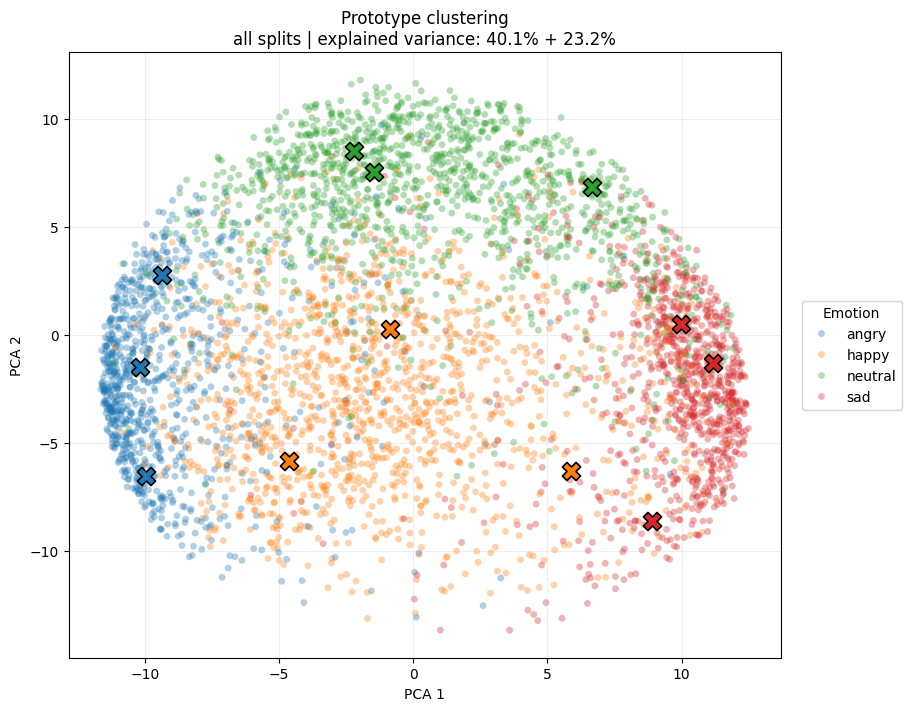

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/prototype_clustering_iemocap_speech_4class_wavlm_large_dur_gt_2_le_15/all_prototype_embedding_pca.png')

In [13]:
from src.utils.visualize import plot_prototype_embedding_pca

prototype_pca_result = plot_prototype_embedding_pca(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    split="all",
    output_path=PROTOTYPE_CLUSTERING_REPORT_DIR / "all_prototype_embedding_pca.png",
    random_state=RANDOM_STATE
)

prototype_pca_result["output_path"]

## 13. Explanation By Example - Inspect Prototype Neighbors of a Test Sample

Inspect one sample using the saved 128D embeddings and saved real prototypes. This does not reprocess the WAV file.

In [28]:
import pandas as pd
from src.explainability.prototype_neighbors import (
    explain_sample_by_filename,
    print_prototype_explanation
)

# Set an IEMOCAP file name here, or leave it as None to sample a different random test example at each rerun.
SAMPLE_TO_EXPLAIN = None

prototype_explanation = explain_sample_by_filename(
    embedding_metadata=pd.read_csv(BLACK_BOX_EMBEDDING_DIR / "metadata.csv"),
    sample_to_explain=SAMPLE_TO_EXPLAIN,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR
)

print_prototype_explanation(prototype_explanation)

Sample:    Session3_00342.wav
True:      happy
Predicted: happy

Class scores:
    angry: 0.0000
    happy: 0.9583
  neutral: 0.0000
      sad: 0.0000

Top-1 prototypes:
  #01   happy | sim 0.9583 | Session3_00807.wav


We can listen to the test sample and its nearest prototypes (medoids).

In [29]:
from IPython.display import Audio, display, Markdown

sample_file = prototype_explanation["file_name"]
display(Markdown(f"### Sample: `{sample_file}`"))
display(Audio(filename=str(AUDIO_DIR / sample_file)))

display(Markdown("### Top prototypes"))
for prototype in prototype_explanation["top_prototypes"]:
    prototype_file = prototype.get("prototype_file_name")

    display(Markdown(
        f"**#{prototype['rank']} | {prototype['prototype_emotion']} | "
        f"similarity: {prototype['similarity']:.4f}**  \n"
        f"`{prototype_file}`"
    ))
    display(Audio(filename=str(AUDIO_DIR / prototype_file)))

### Sample: `Session3_00342.wav`

### Top prototypes

**#1 | happy | similarity: 0.9583**  
`Session3_00807.wav`